# 2-1 샘플 · 코딩으로 많은 데이터를 다루면 어디까지 보일까

**가상 학교 축제 부스 방문 기록 100,000건을 코드로 읽어 하나의 화면으로 정리한 실제 실행 예시입니다.**

- 이 Notebook은 **코딩으로 많은 데이터를 다룬 결과를 미리 보여 주는 샘플**입니다.
- **실제 수행평가 데이터나 정답이 아닙니다.** 모든 내용은 수업용으로 만든 가상 자료입니다.
- **이 대시보드 전체를 여러분이 만들어야 한다는 뜻이 아닙니다.**
- 수행평가 1에서는 **더 단순한 CSV 한 개와 지정된 그래프 한 개**를 완성하게 됩니다.
- AI가 코드를 만들더라도 **결과가 원본 데이터와 맞는지 확인하는 일은 사람이 합니다.**

> 오늘 볼 것: 100,000줄의 표가 코드를 거쳐 어떤 화면으로 바뀌는가.


## 1. AI에게 전달할 수 있는 요청 예시

아래는 실제 대화 기록이 아니라, **이런 식으로 요청할 수 있다**는 예시입니다.

```text
data/01_festival_booth_activity.csv 파일을 읽어 줘.

- 전체 방문자 수와 방문자가 가장 많은 부스를 확인해 줘.
- 부스별 방문자 수를 비교하는 그래프를 만들어 줘.
- 시간대별 방문자 변화를 선그래프로 보여 줘.
- 평균 대기 시간과 만족도의 관계를 산점도로 보여 줘.
- 위 내용을 PPT에 넣을 수 있도록 16:9 대시보드 이미지 한 장으로 저장해 줘.
  저장 경로는 output/01_festival_dashboard.png 로 해 줘.
- 마지막에 결과 숫자가 원본 CSV와 같은지 확인하는 코드도 함께 만들어 줘.
```

요청에 **무엇을 읽고 · 무엇을 보여 주고 · 어디에 저장하고 · 어떻게 확인할지**를 함께 적는 것이 중요합니다.

## 2. 원본 CSV 확인하기

먼저 그래프를 그리기 전에 **어떤 표를 읽었는지** 눈으로 확인합니다.

아래 경로 처리 코드는 이번 차시에 배우는 내용이 아니라, 어느 폴더에서 실행해도 `data` 폴더를 찾도록 **미리 준비해 둔 코드**입니다.

In [1]:
from pathlib import Path

import pandas as pd


def find_project_root(start: Path) -> Path:
    """pyproject.toml과 data 폴더가 함께 있는 위치를 프로젝트 루트로 본다."""
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists() and (candidate / "data").is_dir():
            return candidate
    return start


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
DATA_PATH = PROJECT_ROOT / "data" / "01_festival_booth_activity.csv"
OUTPUT_PATH = PROJECT_ROOT / "output" / "01_festival_dashboard.png"

festival = pd.read_csv(DATA_PATH)

print("읽은 파일:", DATA_PATH.relative_to(PROJECT_ROOT))
festival.head()

읽은 파일: data/01_festival_booth_activity.csv


,visit_id,visited_at,time_slot,booth,category,grade,spent_won,wait_min,satisfaction
0,V000001,2026-09-18 10:06:00,10:00,떡볶이 가게,음식,3,3000,2,4.3
1,V000002,2026-09-18 16:34:00,16:00,사진 부스,체험,1,0,8,4.2
2,V000003,2026-09-18 16:33:00,16:00,방탈출 게임,게임,3,1000,8,4.9
3,V000004,2026-09-18 12:09:00,12:00,방탈출 게임,게임,3,1000,14,4.1
4,V000005,2026-09-18 16:15:00,16:00,사진 부스,체험,3,2000,4,4.7


In [2]:
print("행의 개수:", festival.shape[0])
print("열의 개수:", festival.shape[1])
print("열 이름:", list(festival.columns))
print("비어 있는 값의 개수:", int(festival.isna().sum().sum()))

행의 개수: 100000
열의 개수: 9
열 이름: ['visit_id', 'visited_at', 'time_slot', 'booth', 'category', 'grade', 'spent_won', 'wait_min', 'satisfaction']
비어 있는 값의 개수: 0


표를 그대로 보면 **100,000줄**이라 한 줄씩 읽을 수 없습니다. 코드는 이 기록을 **부스별**과 **시간대별**로 빠르게 묶어 줍니다.


In [3]:
total_visitors = int(len(festival))
mean_satisfaction = round(float(festival["satisfaction"].mean()), 1)

visitors_by_booth = festival.groupby("booth").size().sort_values(ascending=False)
visitors_by_time = festival.groupby("time_slot").size().sort_index()
top_booth = str(visitors_by_booth.index[0])

booth_summary = (
    festival.groupby(["booth", "category"], as_index=False)
    .agg(
        avg_wait_min=("wait_min", "mean"),
        satisfaction=("satisfaction", "mean"),
        visitors=("visit_id", "count"),
    )
)

print("전체 방문 기록:", f"{total_visitors:,}건")
print("평균 만족도:", mean_satisfaction)
print("방문 기록이 가장 많은 부스:", top_booth)
print()
print("[부스별 방문 기록 수]")
print(visitors_by_booth.to_string())
print()
print("[시간대별 방문 기록 수]")
print(visitors_by_time.to_string())


전체 방문 기록: 100,000건
평균 만족도: 4.6
방문 기록이 가장 많은 부스: 떡볶이 가게

[부스별 방문 기록 수]
booth
떡볶이 가게      25314
슬러시 카페      17996
방탈출 게임      16905
다트 챌린지      14882
사진 부스       13832
캘리그라피 체험    11071

[시간대별 방문 기록 수]
time_slot
10:00     6104
11:00     9937
12:00    17999
13:00    22015
14:00    19104
15:00    14966
16:00     9875


## 3. 한 화면으로 정리하기

같은 표를 **숫자 요약 3개 + 그래프 3개**로 바꾼 화면입니다.

In [4]:
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import font_manager
from matplotlib.patches import FancyBboxPatch

# 한글 폰트를 순서대로 찾고, 없으면 영어 표시로 안전하게 바꾼다.
KOREAN_FONT_CANDIDATES = [
    "Apple SD Gothic Neo",  # macOS
    "AppleGothic",          # macOS
    "Malgun Gothic",        # Windows
    "NanumGothic",          # 공통(설치형)
    "Noto Sans CJK KR",     # 공통(설치형)
]

installed_fonts = {f.name for f in font_manager.fontManager.ttflist}
korean_font = next((n for n in KOREAN_FONT_CANDIDATES if n in installed_fonts), None)

if korean_font:
    plt.rcParams["font.family"] = korean_font
plt.rcParams["axes.unicode_minus"] = False

USE_KOREAN = korean_font is not None
print("사용할 폰트:", korean_font if USE_KOREAN else "한글 폰트를 찾지 못해 영어 표시를 사용합니다")

사용할 폰트: Apple SD Gothic Neo


In [5]:
# 한글 폰트가 없을 때 사용할 영어 표시
LABELS_KO = {
    "title": "학교 축제 부스 운영 현황",
    "subtitle": "가상 자료 · 100,000건의 방문 기록을 실제 코드로 처리한 결과",
    "kpi1": "전체 방문자 수", "kpi2": "방문자가 가장 많은 부스", "kpi3": "평균 만족도",
    "unit_people": "명", "unit_score": "점 (5점 만점)",
    "bar": "부스별 방문자 수", "line": "시간대별 방문자 변화",
    "scatter": "평균 대기 시간과 만족도의 관계",
    "x_wait": "평균 대기 시간(분)", "y_sat": "만족도(5점 만점)",
    "x_time": "시간대", "y_visitors": "방문자 수(명)",
}
LABELS_EN = {
    "title": "School Festival Booth Activity",
    "subtitle": "Actual code output from 100,000 fictional visit records",
    "kpi1": "Total visitors", "kpi2": "Busiest booth", "kpi3": "Average satisfaction",
    "unit_people": "", "unit_score": "/ 5",
    "bar": "Visitors by booth", "line": "Visitors by time slot",
    "scatter": "Waiting time vs. satisfaction",
    "x_wait": "Average wait (min)", "y_sat": "Satisfaction (out of 5)",
    "x_time": "Time slot", "y_visitors": "Visitors",
}
BOOTH_EN = {
    "떡볶이 가게": "Tteokbokki", "슬러시 카페": "Slush Cafe", "방탈출 게임": "Escape Room",
    "다트 챌린지": "Dart Challenge", "캘리그라피 체험": "Calligraphy", "사진 부스": "Photo Booth",
}
CATEGORY_EN = {"음식": "Food", "게임": "Game", "체험": "Craft"}

L = LABELS_KO if USE_KOREAN else LABELS_EN
booth_label = (lambda name: name) if USE_KOREAN else (lambda name: BOOTH_EN[name])
category_label = (lambda name: name) if USE_KOREAN else (lambda name: CATEGORY_EN[name])

# 색은 세 가지 분류 색과 강조색 하나로만 통일한다.
CATEGORY_COLOR = {"음식": "#E4794A", "게임": "#2F5D8A", "체험": "#4E9F87"}
BG, CARD, INK, MUTED, GRID = "#F7F8FA", "#FFFFFF", "#1E2A38", "#6B7684", "#E3E7EC"

저장한 파일: output/01_festival_dashboard.png


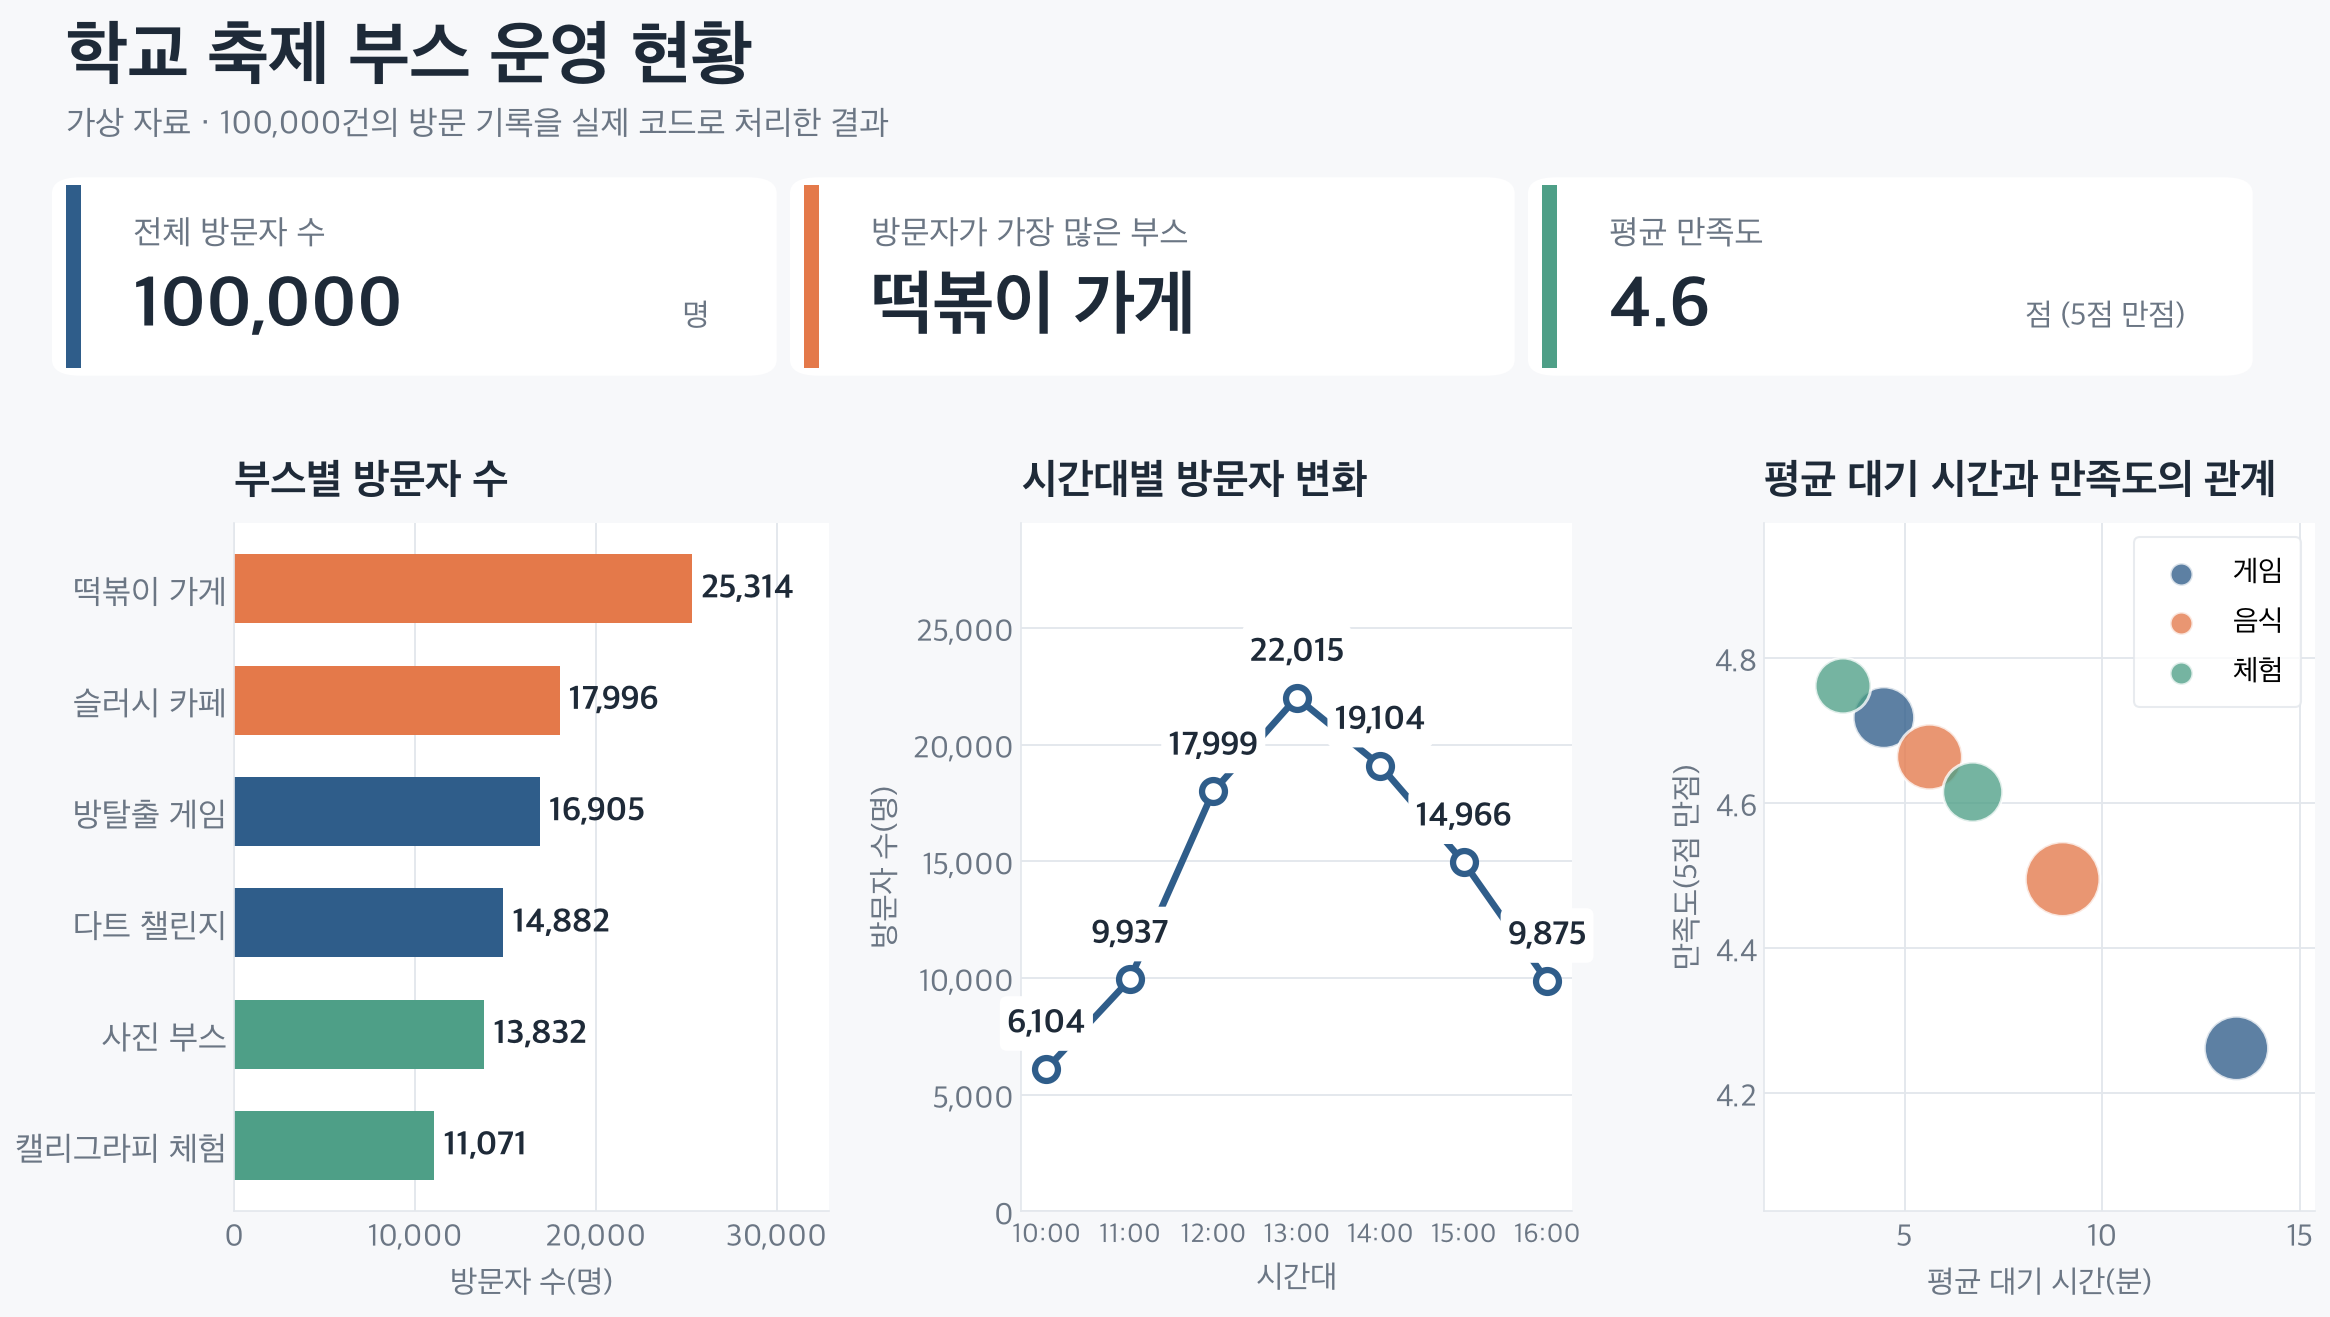

In [6]:
fig = plt.figure(figsize=(16, 9), dpi=150, facecolor=BG)

# ── 제목 ─────────────────────────────────────────────────────────
fig.text(0.045, 0.945, L["title"], fontsize=34, fontweight="bold", color=INK, va="center")
fig.text(0.045, 0.895, L["subtitle"], fontsize=16, color=MUTED, va="center")

# ── 숫자 요약 카드 3개 ───────────────────────────────────────────
kpi_values = [
    (L["kpi1"], f"{total_visitors:,}", L["unit_people"], "#2F5D8A"),
    (L["kpi2"], booth_label(top_booth), "", "#E4794A"),
    (L["kpi3"], f"{mean_satisfaction}", L["unit_score"], "#4E9F87"),
]
card_w, card_h, card_y, gap = 0.29, 0.135, 0.715, 0.0175
for i, (name, value, unit, accent) in enumerate(kpi_values):
    x = 0.045 + i * (card_w + gap)
    fig.patches.append(FancyBboxPatch(
        (x, card_y), card_w, card_h, boxstyle="round,pad=0.006,rounding_size=0.012",
        transform=fig.transFigure, facecolor=CARD, edgecolor="none", zorder=1))
    fig.patches.append(FancyBboxPatch(
        (x, card_y), 0.006, card_h, boxstyle="square,pad=0",
        transform=fig.transFigure, facecolor=accent, edgecolor="none", zorder=2))
    fig.text(x + 0.028, card_y + card_h - 0.036, name, fontsize=16, color=MUTED, va="center")
    fig.text(x + 0.028, card_y + 0.045, value, fontsize=34, fontweight="bold",
             color=INK, va="center")
    if unit:
        fig.text(x + card_w - 0.022, card_y + 0.038, unit, fontsize=15,
                 color=MUTED, va="center", ha="right")

# ── 그래프 3개 ───────────────────────────────────────────────────
# 부스 이름이 길어 왼쪽 여백을 넉넉히 둔다.
grid = fig.add_gridspec(1, 3, left=0.115, right=0.982, top=0.60, bottom=0.09,
                        wspace=0.34, width_ratios=[1.08, 1, 1])
ax_bar, ax_line, ax_scatter = (fig.add_subplot(grid[0, i]) for i in range(3))

for ax in (ax_bar, ax_line, ax_scatter):
    ax.set_facecolor(CARD)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_color(GRID)
    ax.tick_params(colors=MUTED, labelsize=15, length=0)

# (1) 부스별 방문자 수 — 가로 막대
bar_booths = list(visitors_by_booth.index)[::-1]
bar_values = list(visitors_by_booth.values)[::-1]
booth_category = festival.drop_duplicates("booth").set_index("booth")["category"]
ax_bar.barh([booth_label(b) for b in bar_booths], bar_values,
            color=[CATEGORY_COLOR[booth_category[b]] for b in bar_booths], height=0.62)
for y, value in enumerate(bar_values):
    ax_bar.text(value + max(bar_values) * 0.02, y, f"{value:,}", va="center",
                fontsize=16, fontweight="bold", color=INK)
ax_bar.set_xlim(0, max(bar_values) * 1.30)
ax_bar.xaxis.set_major_formatter(lambda v, _: f"{int(v):,}")
ax_bar.set_title(L["bar"], fontsize=20, fontweight="bold", color=INK, pad=14, loc="left")
ax_bar.set_xlabel(L["y_visitors"], fontsize=15, color=MUTED)
ax_bar.tick_params(axis="y", labelsize=16)
ax_bar.xaxis.grid(True, color=GRID, linewidth=0.9)
ax_bar.set_axisbelow(True)

# (2) 시간대별 방문자 변화 — 선그래프
time_labels = list(visitors_by_time.index)
time_values = list(visitors_by_time.values)
ax_line.plot(time_labels, time_values, color="#2F5D8A", linewidth=3.2,
             marker="o", markersize=11, markerfacecolor="#FFFFFF", markeredgewidth=3)
for x, value in zip(time_labels, time_values):
    # 숫자가 선 위에 겹쳐 보이지 않도록 흰 바탕을 깔고 점 위에 띄운다.
    ax_line.annotate(f"{value:,}", (x, value), textcoords="offset points", xytext=(0, 17),
                     ha="center", fontsize=16, fontweight="bold", color=INK,
                     bbox=dict(boxstyle="round,pad=0.22", facecolor=CARD, edgecolor="none"))
ax_line.set_ylim(0, max(time_values) * 1.34)
ax_line.yaxis.set_major_formatter(lambda v, _: f"{int(v):,}")
ax_line.tick_params(axis="x", labelsize=13)  # 시간대 7개가 서로 붙지 않게 한다
ax_line.set_title(L["line"], fontsize=20, fontweight="bold", color=INK, pad=14, loc="left")
ax_line.set_xlabel(L["x_time"], fontsize=15, color=MUTED)
ax_line.set_ylabel(L["y_visitors"], fontsize=15, color=MUTED)
ax_line.yaxis.grid(True, color=GRID, linewidth=0.9)
ax_line.set_axisbelow(True)

# (3) 대기 시간과 만족도 — 산점도 (점 하나가 부스 하나, 크기는 방문 기록 수)
busiest = booth_summary["visitors"].max()
for category, group in booth_summary.groupby("category", sort=False):
    ax_scatter.scatter(group["avg_wait_min"], group["satisfaction"],
                       s=280 + 1000 * group["visitors"] / busiest, alpha=0.78,
                       color=CATEGORY_COLOR[category], edgecolor="white", linewidth=1.4,
                       label=category_label(category))
ax_scatter.set_title(L["scatter"], fontsize=20, fontweight="bold", color=INK, pad=14, loc="left")
ax_scatter.set_xlabel(L["x_wait"], fontsize=15, color=MUTED)
ax_scatter.set_ylabel(L["y_sat"], fontsize=15, color=MUTED)
sat_low, sat_high = booth_summary["satisfaction"].min(), booth_summary["satisfaction"].max()
sat_pad = (sat_high - sat_low) * 0.45
ax_scatter.set_ylim(sat_low - sat_pad, sat_high + sat_pad)
ax_scatter.margins(x=0.20)
ax_scatter.grid(True, color=GRID, linewidth=0.9)
ax_scatter.set_axisbelow(True)
legend = ax_scatter.legend(fontsize=14, loc="upper right", frameon=True,
                           facecolor=CARD, edgecolor=GRID, borderpad=0.6)
for handle in legend.legend_handles:
    handle.set_sizes([120])

fig.savefig(OUTPUT_PATH, facecolor=BG)
print("저장한 파일:", OUTPUT_PATH.relative_to(PROJECT_ROOT))
plt.show()

## 4. 원본 데이터와 맞는지 확인하기

**코드가 실행된 것과 원하는 결과가 나온 것은 다릅니다.** 화면에 그려진 값을 원본 CSV와 하나씩 대조합니다.

In [7]:
checks = []

# (1) 카드의 전체 방문자 수 = CSV의 행 개수
checks.append(("카드의 전체 방문자 수", total_visitors == len(festival),
               f"{total_visitors:,} / CSV 행 {len(festival):,}"))

# (2) 막대그래프의 가장 긴 막대 = 부스별 방문 기록 수 1위
drawn_bars = {t.get_text(): p.get_width() for t, p in
              zip(ax_bar.get_yticklabels(), ax_bar.patches)}
longest_bar = max(drawn_bars, key=drawn_bars.get)
checks.append(("막대그래프의 1위 부스", longest_bar == booth_label(top_booth),
               f"{longest_bar} / 그룹별 집계 1위 {booth_label(top_booth)}"))

# (3) 막대 개수 = CSV의 부스 개수
checks.append(("막대 개수", len(ax_bar.patches) == festival["booth"].nunique(),
               f"{len(ax_bar.patches)}개 / CSV의 부스 {festival['booth'].nunique()}개"))

# (4) 선그래프의 시간대 = CSV의 시간대
drawn_times = [t.get_text() for t in ax_line.get_xticklabels()]
csv_times = sorted(festival["time_slot"].unique())
checks.append(("선그래프의 시간대", drawn_times == csv_times,
               f"{drawn_times} / CSV {csv_times}"))

# (5) 산점도 = 부스별 평균 대기 시간과 평균 만족도
drawn_points = sorted((round(float(p[0]), 6), round(float(p[1]), 6))
                      for c in ax_scatter.collections for p in c.get_offsets())
summary_points = sorted((round(float(row.avg_wait_min), 6), round(float(row.satisfaction), 6))
                        for row in booth_summary.itertuples())
checks.append(("산점도의 부스별 요약값", drawn_points == summary_points,
               f"{len(drawn_points)}개 점 / 부스별 요약 {len(summary_points)}개"))

for name, ok, detail in checks:
    print(f"[{'일치' if ok else '불일치'}] {name}: {detail}")


[일치] 카드의 전체 방문자 수: 100,000 / CSV 행 100,000
[일치] 막대그래프의 1위 부스: 떡볶이 가게 / 그룹별 집계 1위 떡볶이 가게
[일치] 막대 개수: 6개 / CSV의 부스 6개
[일치] 선그래프의 시간대: ['10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00'] / CSV ['10:00', '11:00', '12:00', '13:00', '14:00', '15:00', '16:00']
[일치] 산점도의 부스별 요약값: 6개 점 / 부스별 요약 6개


## 5. 사람이 확인한 결과

원본 CSV **100,000행**과 완성된 대시보드를 직접 대조합니다.

- 카드의 전체 방문자 수가 CSV의 **100,000개 방문 기록**과 같은지 확인합니다.
- 방문 기록이 가장 많은 부스가 막대그래프의 가장 긴 막대와 같은지 확인합니다.
- 그래프에 나온 부스와 시간대의 개수가 원본 CSV와 같은지 확인합니다.
- 산점도의 점이 부스별 평균 대기 시간과 평균 만족도를 올바르게 나타내는지 확인합니다.

> 코드가 오류 없이 끝났다는 사실만으로 완료하지 않습니다. **원본과 결과를 대조한 뒤에** 맞는 결과라고 판단합니다.

**다시 확인**: 이 자료는 수업 흥미를 위한 가상 예시이며, 수행평가 1에서는 더 단순한 CSV로 **지정된 그래프 한 개**를 완성합니다.
